In [ ]:
# 공통 처리

# 불필요한 경고 메시지 무시
import warnings
from itertools import groupby
from pydoc import describe

import matplotlib
import seaborn
from matplotlib.pyplot import fill_between
from mlxtend.evaluate import feature_importance_permutation
from nbformat.sign import algorithms
from pandas import value_counts
from xgboost import XGBRegressor, plot_importance

warnings.filterwarnings('ignore')

# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 글꼴 설정
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='batang')

# 숫자 출력 조정
# 넘파이 부동소수점 출력 자리수 설정
np.set_printoptions(suppress=True, precision=4)

# 판다스 부동소수점 출력 자리수 설정
pd.options.display.float_format = '{:.4f}'.format

# 데이터프레임 모든 필드 출력
pd.set_option('display.max_columns', None)

# 그래프 글꼴 크기 설정
plt.rcParams['font.size'] = 14

# 난수 시드
random_seed = 123

In [37]:
import sklearn
sklearn.__version__

'1.6.1'

In [2]:
### 04_데이터 읽어들이기부터 데이터 확인까지

In [7]:
### 01. 데이터 읽어들이기

In [7]:
df = pd.read_csv('./input/Wholesale_customers_data.csv')

In [8]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [9]:
# 우리말 필드명 정의
columns = ['판매_채널', '지역', '신선식품', '유제품', '식료품',
    '냉동식품', '세제_종이제품', '부식']
df.columns = columns

In [10]:
df.head()

,판매_채널,지역,신선식품,유제품,식료품,냉동식품,세제_종이제품,부식
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [11]:
### 02. 데이터 확인하기

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   판매_채널    440 non-null    int64
 1   지역       440 non-null    int64
 2   신선식품     440 non-null    int64
 3   유제품      440 non-null    int64
 4   식료품      440 non-null    int64
 5   냉동식품     440 non-null    int64
 6   세제_종이제품  440 non-null    int64
 7   부식       440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [13]:
# 건수 확인
df.shape

(440, 8)

In [14]:
# 누락 값 확인
df.isnull().sum()

판매_채널      0
지역         0
신선식품       0
유제품        0
식료품        0
냉동식품       0
세제_종이제품    0
부식         0
dtype: int64

In [15]:
# 누락 값이 없음

In [16]:
# 판매 채널과 지역 필드의 레이블 값 확인

# '판매 채널'의 레이블 값 확인
df['판매_채널'].value_counts()

판매_채널
1    298
2    142
Name: count, dtype: int64

In [17]:
# '지역'의 레이블값 확인
df['지역'].value_counts()

지역
3    316
1     77
2     47
Name: count, dtype: int64

In [18]:
# 각 레이블의 의미

# * 판매 채널 필드 레이블값의 의미
# 1. Horeca(호텔, 레스토랑, 카페) - 298
# 2. Retail(소매점) - 142

# * 지역 필드 레이블값의 의미
# 1. Lisbon(리스본) - 77
# 2. Oporto(포르투) - 47
# 3. Other Region(기타) - 316

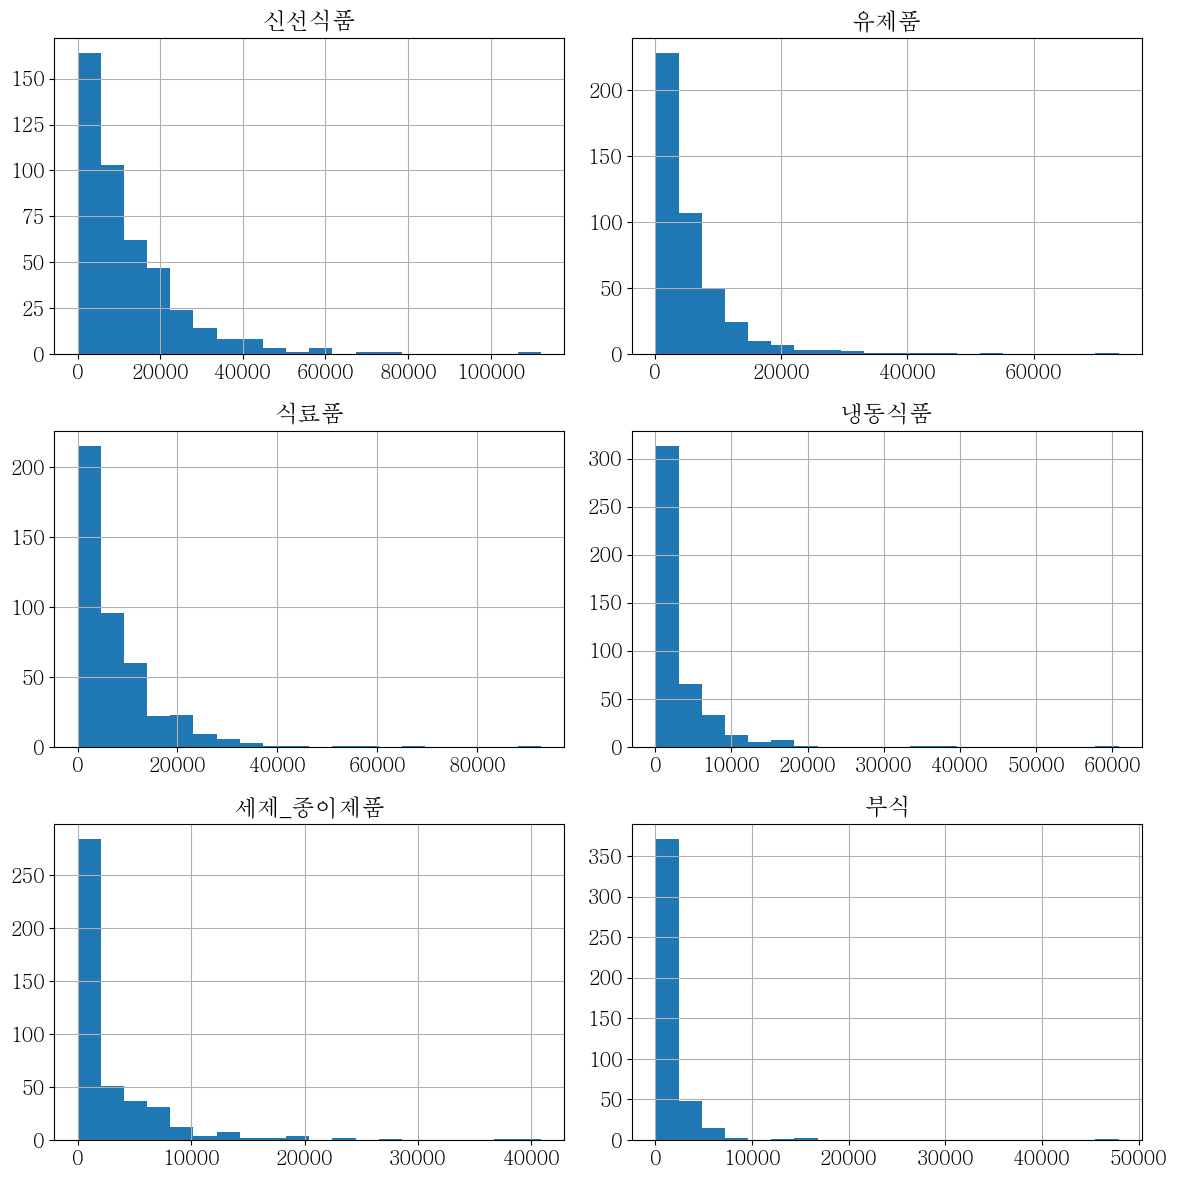

In [19]:
# 히스토그램 그림

# '판매_채널'과 '지역'을 ㅈ[외
df2 = df.drop(['판매_채널', '지역'], axis=1)

# 대상 필드의 히스토그램을 그리기
from pylab import rcParams
rcParams['figure.figsize'] = (12, 12)
df2.hist(bins=20)
plt.tight_layout()
plt.show()

In [20]:
# 전체 데이터에서 '판매_채널', '지역' 필드를 제외한 df2를 만듬
# 이 데이터는 나중에 클러스터링, 차원축소에 그대로 입력 데이터로 사용

# 여섯 개 필드 모두에서 가격이 가장 낮은 물건이 구매 빈도가 가장 높았고, 가격이 올라감에 따라 빈도가 서서히 낮아지는 경향을 보임

In [21]:
### 05_클러스터링

In [22]:
# 데이터 전처리가 필요없음
# 전처리가 불필요한 이유는 이 데이터가 누락 값이 없는 깔끔한 상태이기도 하고, 히스토그램을 그리면서 판매 채널과 지역 컬럼을 제거
# 비지도 학습의 특성상 데이터 분할 단계도 불필요하므로 알고리즘 선택 단계로 감

In [23]:
# 알고리즘 선택하기

# 알고리즘 선택
from sklearn.cluster import KMeans

# 클러스터 수를 지정
clusters = 4

# 알고리즘 정의
algorithm = KMeans(n_clusters=clusters, random_state=random_seed)

In [24]:
# 클러스터링에서 가장 일반적으로 쓰이는 알고리즘인 K-평균 (k-means) 알고리즘을 사용
# K-평균 알고리즘을 사용할 때는 주의할 점이 있는데, 처음에 클러스터 수를 미리 지정해야 함
# 클러스터 수를 지정할 때는 n_cluster 파라미터를 사용. 모델을 이용할 때 이 값이 중요하지만, 간단한 설명을 위해
# 클러스터 수를 4로 정하고 구현을 진행

In [25]:
# 지도 학습이라면 학습 및 예측 단계가 이어지지만, 비지도 학습에서는 이 단계가 약간 달라짐

# 학습 및 예측
y_pred = algorithm.fit_predict(df2)

# 결과 중 일부를 확인
print(y_pred[:20])

[2 2 2 1 1 2 2 2 2 0 2 2 1 1 1 2 2 2 1 2]


In [26]:
# 비지도 학습에서는 학습과 예측이 동시에 일어남
# 그래서 함수 이름도 학습 (fit)과 예측 (predict)이 하나가 된 fit_predict이며 이름 그대로 학습과 예측을 동시에 수행하고
# 예측 결과 (여기서는 각 데이터 점이 속하는 그룹)을 반환
# 확인을 위해 예측 결과가 저장된 변수 y_pred의 일부를 화면에 출력
# 예상대로 0부터 3까지의 숫자가 담긴 배열이 출력

In [27]:
### 06_클러스터링 결과 분석

In [28]:
# 클러스터링 결과를 이용하는 과정

In [29]:
### 1. 그룹별 평균 계산하기

In [30]:
# 먼저 그룹별 각 필드의 평균값을 계산
# 각 그룹의 특징을 파악하는 것이 목표
# 데이터프레임 객체의 groupby 함수를 사용하면 간단한 코드로 처리할 수 있음

In [31]:
# 그룹별 평균 계산하기
df_cluster = df2.groupby(y_pred).mean()
df_cluster

,신선식품,유제품,식료품,냉동식품,세제_종이제품,부식
0,8149.8367,18715.8571,27756.5918,2034.7143,12523.0204,2282.1429
1,20801.0796,3794.0088,5013.4513,4023.3363,1119.7080,1648.3451
2,5473.1765,4108.3216,5592.8745,2254.8706,1983.6510,1051.0902
3,49330.7391,6823.2609,6338.5217,9666.0870,950.9130,4557.6957


In [32]:
### 2. 그룹별 평균을 그래프로 나타내기

In [33]:
# 숫자의 나열만으로는 경향을 파악하기가 어려움
# 그룹별 평균을 그래프로 나타냄

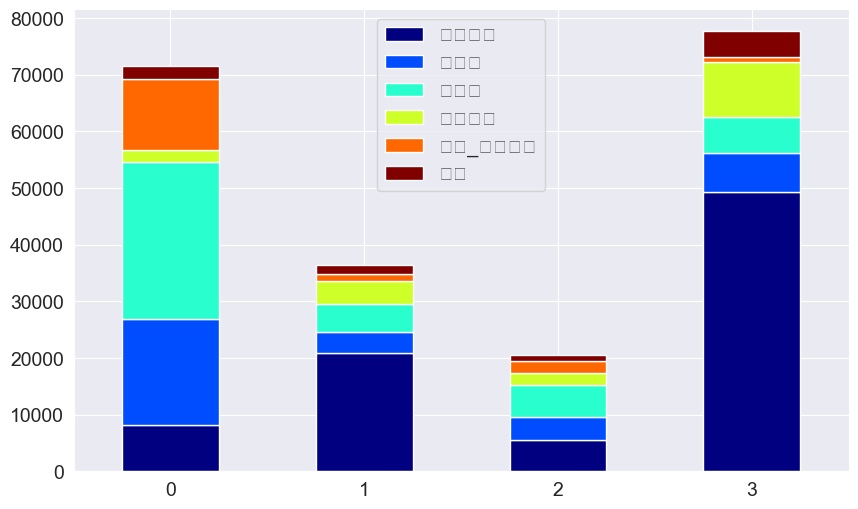

In [34]:
# 그룹별 평균을 막대그래프로
df_cluster.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='jet')
plt.xticks(rotation=0)
plt.show()